<a href="https://colab.research.google.com/github/ba4351127-code/student_marks_prediction/blob/main/students_marks_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# Set a random seed so the results are reproducible
np.random.seed(42)

# 1. Generate 100 samples of Study Hours (ranging from 1 to 10 hours)
study_hours = np.random.uniform(1.0, 10.0, 100)

# 2. Define a realistic relationship: Marks = (Base Marks) + (Effect of hours) + Random Noise

noise = np.random.normal(0, 5, 100) # Mean 0, Standard Deviation 5 (the "noise")
student_marks = 30 + (6.5 * study_hours) + noise

# 3. Clip marks to a realistic max score of 100
student_marks = np.clip(student_marks, 0, 100)

# 4. Combine into a Pandas DataFrame and save it
df = pd.DataFrame({
    'Study_Hours': np.round(study_hours, 1),
    'Marks': np.round(student_marks, 1)
})

# Save to CSV so you have your physical dataset!
df.to_csv('student_marks_dataset.csv', index=False)
print("Dataset created and saved successfully!")

Dataset created and saved successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('student_marks_dataset.csv')

# 2. Separate Features (X) and Target (y)
# Sklearn expects X to be a 2D array (DataFrame) and y to be 1D (Series)
X = df[['Study_Hours']]
y = df['Marks']

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training complete.")

# 5. Evaluate the Model on Test Data
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}") # Closer to 1.0 means a better fit

# 6. Make a Custom Prediction!

custom_hours = [[7.5]]
predicted_score = model.predict(custom_hours)
print(f"\nPredicted Marks for {custom_hours[0][0]} study hours: {predicted_score[0]:.1f}")

Model training complete.
Mean Squared Error: 16.19
R-squared Score: 0.95

Predicted Marks for 7.5 study hours: 78.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


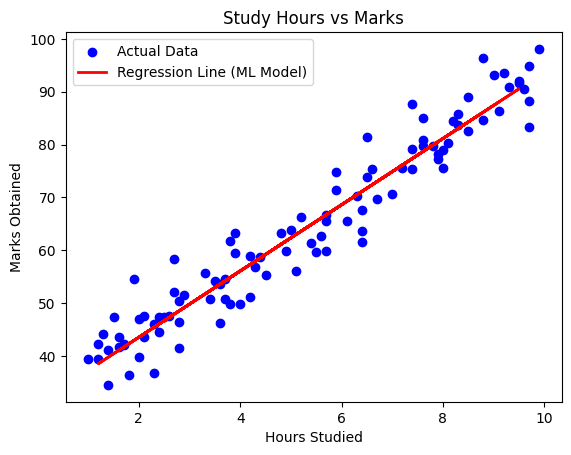

In [3]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line (ML Model)')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Obtained')
plt.title('Study Hours vs Marks')
plt.legend()
plt.show()

In [4]:
import gradio as gr
import numpy as np

def predict_student_marks(hours):
    try:

        hours_input = np.array([[float(hours)]])


        if 'poly' in globals():
            hours_transformed = poly.transform(hours_input)
            prediction = poly_model.predict(hours_transformed)
        elif 'poly_perfect' in globals():
            hours_transformed = poly_perfect.transform(hours_input)
            prediction = perfect_model.predict(hours_transformed)
        else:

            prediction = model.predict(hours_input)

        final_score = prediction.flatten()[0]


        final_score = np.clip(final_score, 0, 100)

        return f"{final_score:.1f} Marks"

    except Exception as e:
            return f"Error: {str(e)}"

# 2. Gradio Interface
demo = gr.Interface(
    fn=predict_student_marks,
    inputs=gr.Number(label="Enter Your study Hours(1 se 20)", value=5.0),
    outputs=gr.Text(label="Predicted Marks obtained"),
    title=" Student Marks Predictor ML App",
    description="Enter your daily study hours and this model predict your marks!"
)

# 3. Launch the app
demo.launch(inline=True, share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>